In [34]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, str(Path("..").resolve()))

ANALYSIS_DIR = Path("../data/analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("../data/output")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {
    "full":           "#2196F3",
    "no_formulation": "#FF9800",
    "zero_shot":      "#4CAF50",
}
EVAL_MODELS = {
    "gpt-5.4", "gpt-5.4-mini", "gpt-4o-mini",
    "claude-sonnet-4-6", "claude-haiku-4-5",
    "gemini-2.5-flash", "gemini-2.5-pro",
    "deepseek-chat", "deepseek-reasoner",
    "qwen2.5-32b", "qwen3.6-35b",
}
print("Ready")

Ready


## 1. Load vignettes (cached)

In [37]:
DF_CACHE = ANALYSIS_DIR / "all_vignettes.parquet"

if DF_CACHE.exists():
    df = pd.read_parquet(DF_CACHE)
    print(f"Loaded {len(df)} cached vignettes")
else:
    from utils.text import strip_markdown
    rows = []
    for condition_dir in sorted(OUTPUT_DIR.iterdir()):
        if not condition_dir.is_dir() or condition_dir.name.startswith("_"):
            continue
        cond = condition_dir.name
        for model_dir in sorted(condition_dir.iterdir()):
            if not model_dir.is_dir() or model_dir.name not in EVAL_MODELS:
                continue
            model = model_dir.name
            for fp in sorted(model_dir.glob("experiment_*.json")):
                try:
                    with open(fp, encoding="utf-8") as f:
                        data = json.load(f)
                    text = strip_markdown(data.get("vignette", ""))
                    if not text:
                        continue
                    pid = data.get("persona_id") or data.get("source_persona_id")
                    rows.append({"persona_id": pid, "model": model,
                                 "condition": cond, "vignette": text,
                                 "word_count": len(text.split())})
                except Exception:
                    continue
    df = pd.DataFrame(rows)
    df.to_parquet(DF_CACHE, index=False)
    print(f"Saved -> {DF_CACHE}")

print(f"Total: {len(df)} vignettes, {df['persona_id'].nunique()} personas")
df.groupby(["condition", "model"]).size().unstack(fill_value=0)

Loaded 16144 cached vignettes
Total: 16144 vignettes, 500 personas


model,claude-haiku-4-5,claude-sonnet-4-6,deepseek-chat,deepseek-reasoner,gemini-2.5-flash,gemini-2.5-pro,gpt-4o-mini,gpt-5.4,gpt-5.4-mini,qwen2.5-32b,qwen3.6-35b
condition,,,,,,,,,,,
full,500,500,500,499,499,500,500,500,500,500,500
no_formulation,500,500,500,500,500,500,500,500,500,500,499
zero_shot,500,500,500,500,484,163,500,500,500,500,500


## 2. Load all-mpnet-base-v2 embeddings (cached)
768-d, L2-normalised. Delete `embeddings_mpnet.npy` to recompute (~10 min).

In [36]:
from sentence_transformers import SentenceTransformer

EMB_CACHE = ANALYSIS_DIR / "embeddings_mpnet.npy"

if EMB_CACHE.exists():
    embeddings = np.load(EMB_CACHE)
    print(f"Loaded cached embeddings: {embeddings.shape}")
    assert len(embeddings) == len(df), (
        f"Cache mismatch: {len(embeddings)} vs {len(df)} rows. "
        f"Delete {EMB_CACHE} and rerun."
    )
else:
    print(f"Computing embeddings for {len(df)} vignettes (~10 min)...")
    enc = SentenceTransformer("all-mpnet-base-v2")
    embeddings = enc.encode(
        df["vignette"].tolist(),
        show_progress_bar=True,
        batch_size=32,
        normalize_embeddings=True,
    )
    np.save(EMB_CACHE, embeddings)
    print(f"Saved -> {EMB_CACHE}  shape={embeddings.shape}")

Computing embeddings for 16144 vignettes (~10 min)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/505 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 3. UMAP — per model × condition (cached)

Loaded cached UMAP coords: ['full', 'no_formulation', 'zero_shot']


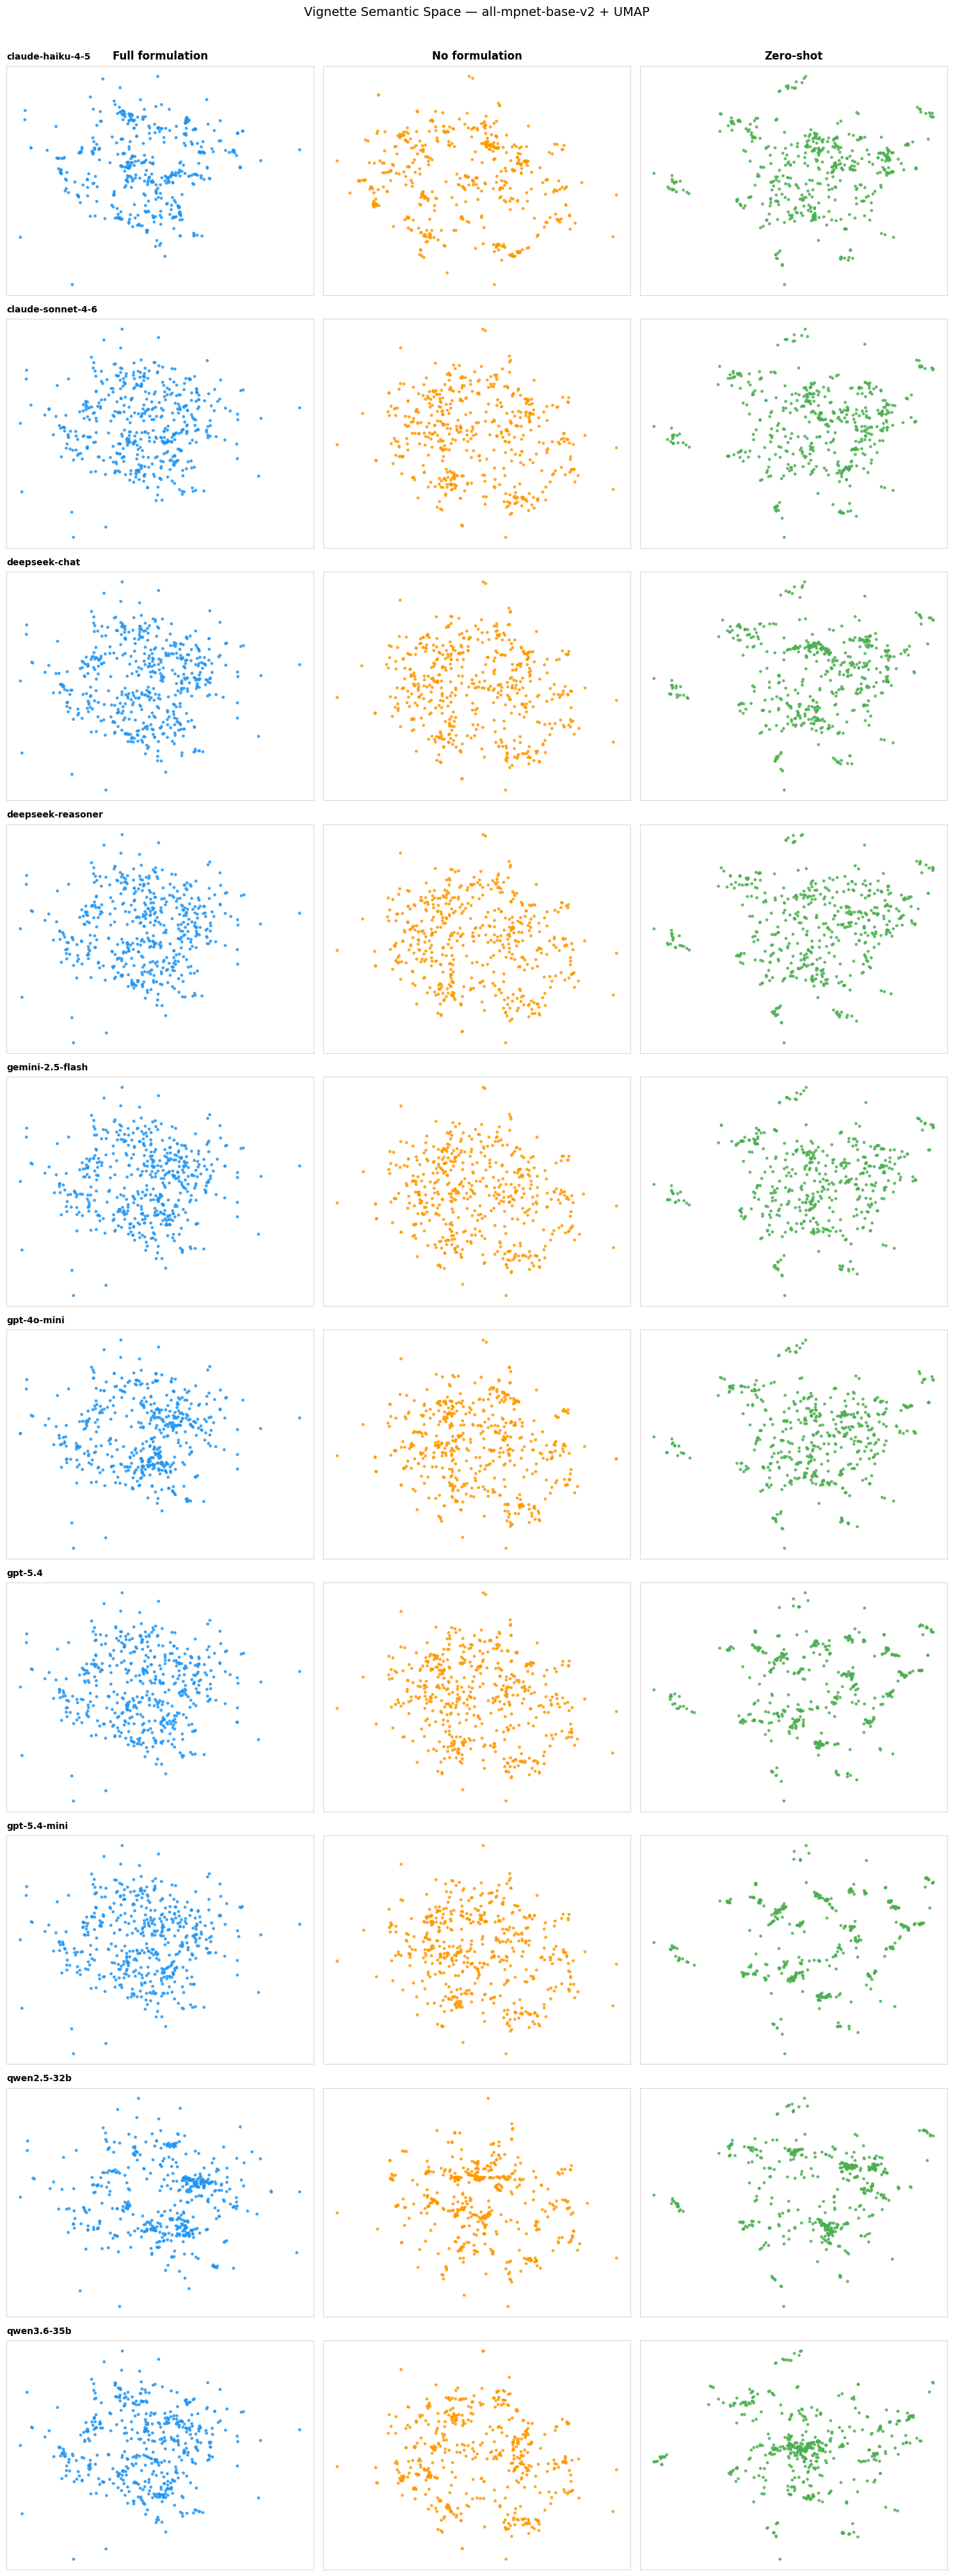

Saved -> ..\data\analysis/umap_per_model_grid_mpnet.png


In [ ]:
import umap

UMAP_CACHE = ANALYSIS_DIR / "umap_coords_per_condition_mpnet.npz"
N_NEIGHBORS = 5

if UMAP_CACHE.exists():
    _c = np.load(UMAP_CACHE)
    umap_coords = {k: _c[k] for k in _c.files}
    print("Loaded cached UMAP coords:", list(umap_coords.keys()))
else:
    umap_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df["condition"] == cond].index.tolist()
        embs = embeddings[idx]
        print(f"{CONDITION_LABELS[cond]}: {len(idx)} vignettes...")
        coords = umap.UMAP(n_components=2, n_neighbors=N_NEIGHBORS,
                           min_dist=0.1, random_state=42).fit_transform(embs)
        umap_coords[cond] = coords
    np.savez(UMAP_CACHE, **umap_coords)
    print(f"Saved -> {UMAP_CACHE}")

models     = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = umap_coords[cond]
        model_mask = (cond_df["model"] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color("#cccccc")
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_title(model, loc="left", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("Vignette Semantic Space — all-mpnet-base-v2 + UMAP",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_per_model_grid_mpnet.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/umap_per_model_grid_mpnet.png")

## 4. t-SNE — per model × condition (cached)

Loaded cached t-SNE coords: ['full', 'no_formulation', 'zero_shot']


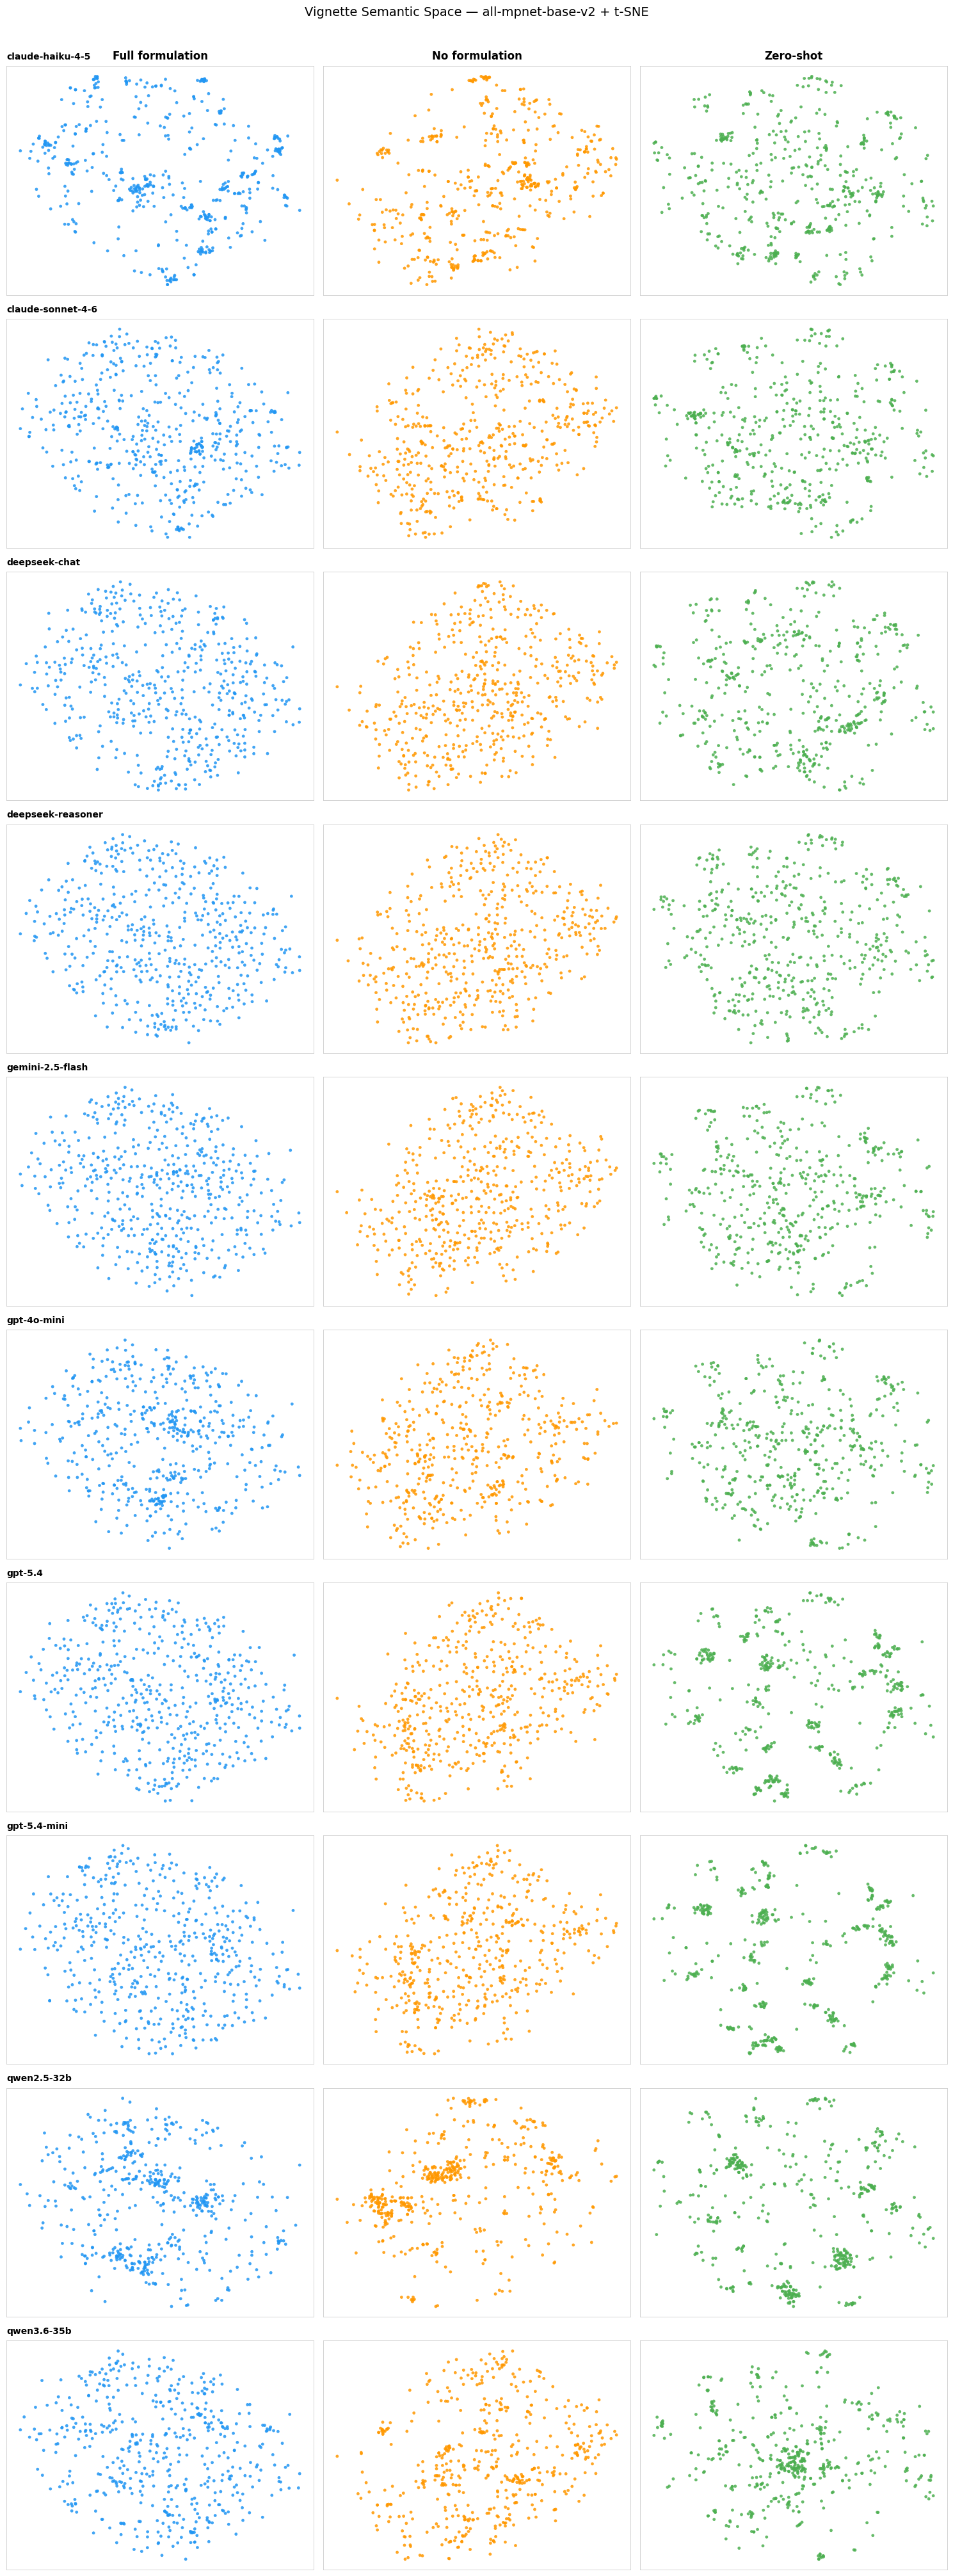

Saved -> ..\data\analysis/tsne_per_model_grid_mpnet.png


In [ ]:
from sklearn.manifold import TSNE

TSNE_CACHE = ANALYSIS_DIR / "tsne_coords_per_condition_mpnet.npz"

if TSNE_CACHE.exists():
    _c = np.load(TSNE_CACHE)
    tsne_coords = {k: _c[k] for k in _c.files}
    print("Loaded cached t-SNE coords:", list(tsne_coords.keys()))
else:
    tsne_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df["condition"] == cond].index.tolist()
        embs = embeddings[idx]
        print(f"{CONDITION_LABELS[cond]}: running t-SNE on {len(idx)} vignettes...")
        coords = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                      init="pca", random_state=42, n_jobs=-1).fit_transform(embs)
        tsne_coords[cond] = coords
        print(f"  done {coords.shape}")
    np.savez(TSNE_CACHE, **tsne_coords)
    print(f"Saved -> {TSNE_CACHE}")

models     = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = tsne_coords[cond]
        model_mask = (cond_df["model"] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color("#cccccc")
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_title(model, loc="left", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("Vignette Semantic Space — all-mpnet-base-v2 + t-SNE",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tsne_per_model_grid_mpnet.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/tsne_per_model_grid_mpnet.png")

## 5. Mean pairwise cosine distance — per model × condition

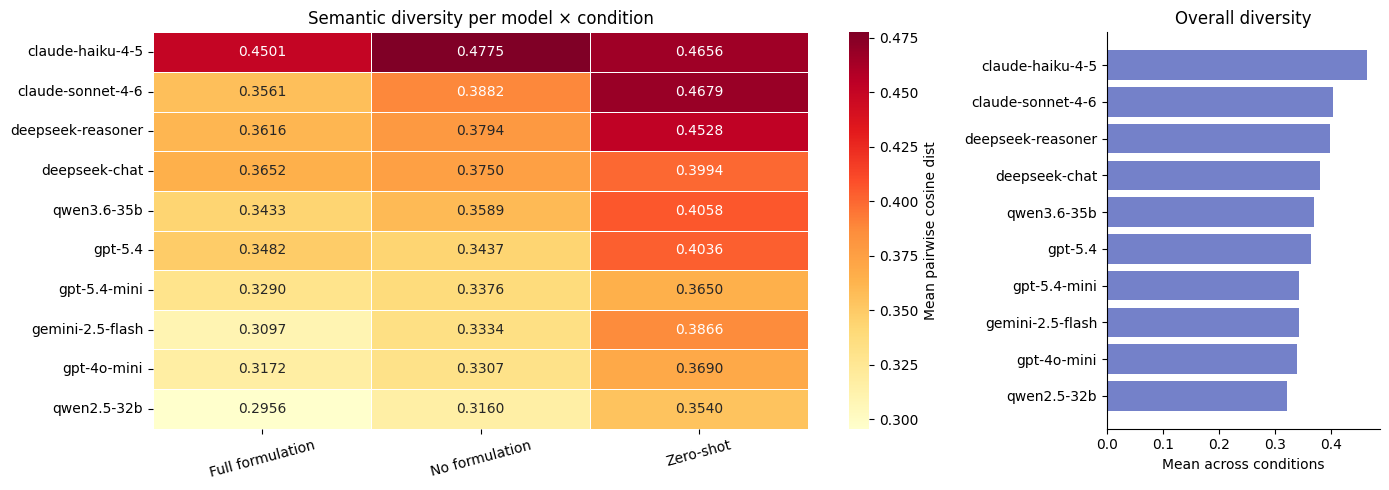

condition,Full formulation,No formulation,Zero-shot,mean
model,,,,
claude-haiku-4-5,0.4501,0.4775,0.4656,0.464400
claude-sonnet-4-6,0.3561,0.3882,0.4679,0.404067
deepseek-reasoner,0.3616,0.3794,0.4528,0.397933
deepseek-chat,0.3652,0.3750,0.3994,0.379867
qwen3.6-35b,0.3433,0.3589,0.4058,0.369333
gpt-5.4,0.3482,0.3437,0.4036,0.365167
gpt-5.4-mini,0.3290,0.3376,0.3650,0.343867
gemini-2.5-flash,0.3097,0.3334,0.3866,0.343233
gpt-4o-mini,0.3172,0.3307,0.3690,0.338967


In [ ]:
rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        embs = embeddings[idx]
        dists = pairwise_distances(embs, metric="cosine")
        upper = dists[np.triu_indices_from(dists, k=1)]
        rows.append({"model": model, "condition": label,
                     "mean_dist": round(float(upper.mean()), 4)})

cosine_df = pd.DataFrame(rows)
pivot = cosine_df.pivot(index="model", columns="condition", values="mean_dist")
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

data = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=axes[0], annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean pairwise cosine dist"})
axes[0].set_title("Semantic diversity per model × condition", fontsize=12)
axes[0].set_xlabel(""); axes[0].set_ylabel("")
axes[0].tick_params(axis="x", rotation=15)

axes[1].barh(pivot.index, pivot["mean"], color="#5C6BC0", alpha=0.85)
axes[1].set_xlabel("Mean across conditions", fontsize=10)
axes[1].set_title("Overall diversity", fontsize=12)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_per_model_heatmap_mpnet.png", dpi=150, bbox_inches="tight")
plt.show()
pivot

## 6. Silhouette score — per condition
- **S_model**: do models produce distinct clusters within a condition?  
- **S_persona**: does persona drive semantic content?

Near +1 → label predicts clusters. Near 0 → interleaved.

Full formulation        S_model=-0.0108  S_persona=0.1193
No formulation          S_model=-0.0042  S_persona=0.0914
Zero-shot               S_model=0.0084  S_persona=0.0585


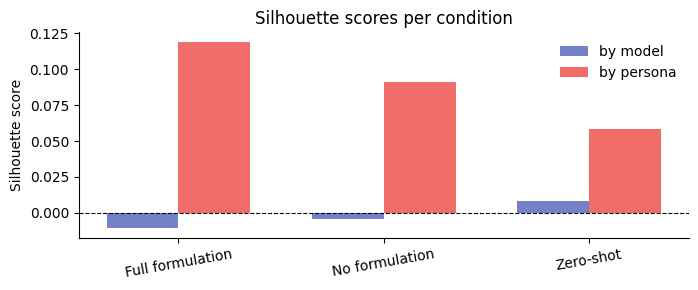

,Silhouette (model),Silhouette (persona)
Condition,,
Full formulation,-0.0108,0.1193
No formulation,-0.0042,0.0914
Zero-shot,0.0084,0.0585


In [ ]:
sil_rows = []
for cond, label in CONDITION_LABELS.items():
    idx      = df[df["condition"] == cond].index
    embs     = embeddings[idx]
    labels_m = LabelEncoder().fit_transform(df.loc[idx, "model"])
    labels_p = LabelEncoder().fit_transform(df.loc[idx, "persona_id"])
    s_m = silhouette_score(embs, labels_m, metric="cosine")
    s_p = silhouette_score(embs, labels_p, metric="cosine")
    sil_rows.append({"Condition": label,
                     "Silhouette (model)": round(s_m, 4),
                     "Silhouette (persona)": round(s_p, 4)})
    print(f"{label:<22}  S_model={s_m:.4f}  S_persona={s_p:.4f}")

sil_df = pd.DataFrame(sil_rows).set_index("Condition")

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(sil_df))
w = 0.35
ax.bar(x - w/2, sil_df["Silhouette (model)"],   width=w, label="by model",   color="#5C6BC0", alpha=0.85)
ax.bar(x + w/2, sil_df["Silhouette (persona)"], width=w, label="by persona", color="#EF5350", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(sil_df.index, rotation=10)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette scores per condition")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "silhouette_mpnet.png", dpi=150, bbox_inches="tight")
plt.show()
sil_df

## 7. Vendi Score — per model × condition
Effective number of distinct vignettes. Rewards uniform spread, penalises clustering.  
Higher = more diverse.

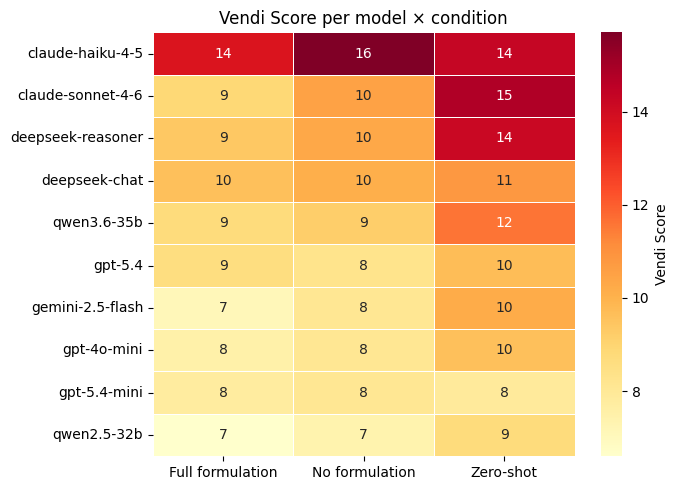

condition,Full formulation,No formulation,Zero-shot,mean
model,,,,
claude-haiku-4-5,13.7,15.7,14.3,14.566667
claude-sonnet-4-6,8.9,10.5,14.8,11.400000
deepseek-reasoner,9.4,10.3,14.2,11.300000
deepseek-chat,9.6,10.1,10.8,10.166667
qwen3.6-35b,8.7,9.2,11.6,9.833333
gpt-5.4,8.6,8.3,9.7,8.866667
gemini-2.5-flash,7.1,8.1,10.2,8.466667
gpt-4o-mini,7.5,8.1,9.6,8.400000
gpt-5.4-mini,7.8,8.1,7.9,7.933333


In [ ]:
def vendi_score(embs):
    n = len(embs)
    K = embs @ embs.T
    K = K / n
    eigvals = np.linalg.eigvalsh(K)
    eigvals = eigvals[eigvals > 1e-10]
    eigvals /= eigvals.sum()
    return float(np.exp(-np.sum(eigvals * np.log(eigvals))))

rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        rows.append({"model": model, "condition": label,
                     "vendi_score": round(vendi_score(embeddings[idx]), 1)})

vendi_df = pd.DataFrame(rows)
pivot_v  = vendi_df.pivot(index="model", columns="condition", values="vendi_score")
pivot_v  = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot_v["mean"] = pivot_v.mean(axis=1)
pivot_v  = pivot_v.sort_values("mean", ascending=False)
pivot_v.to_csv(ANALYSIS_DIR / "vendi_per_model_mpnet.csv")

fig, ax = plt.subplots(figsize=(7, 5))
data = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Vendi Score"})
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Vendi Score per model × condition", fontsize=12)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "vendi_heatmap_mpnet.png", dpi=150, bbox_inches="tight")
plt.show()
pivot_v

## 8. Emotion profile — j-hartmann/emotion-english-distilroberta-base
7 Ekman emotions per vignette (anger, disgust, fear, joy, neutral, sadness, surprise).  
Cached to `emotion_scores.parquet`. Delete cache to recompute (~10–15 min on CPU).

## 11. E&C Component Alignment — self-report pool anchors
For each vignette, compute cosine similarity to each E&C node's self-report item embeddings.  
Uses the same all-mpnet-base-v2 model. Cached to `component_alignment.parquet`.

Loaded 14981 vignettes + embeddings

Component phrase counts:
  Triggers                  137 phrases
  Memory                    39 phrases
  Negative Appraisals       58 phrases
  Threat                    39 phrases
  Maladaptive Strategies    130 phrases

Loaded cached component embeddings
Loaded cached alignment scores: 14981 rows


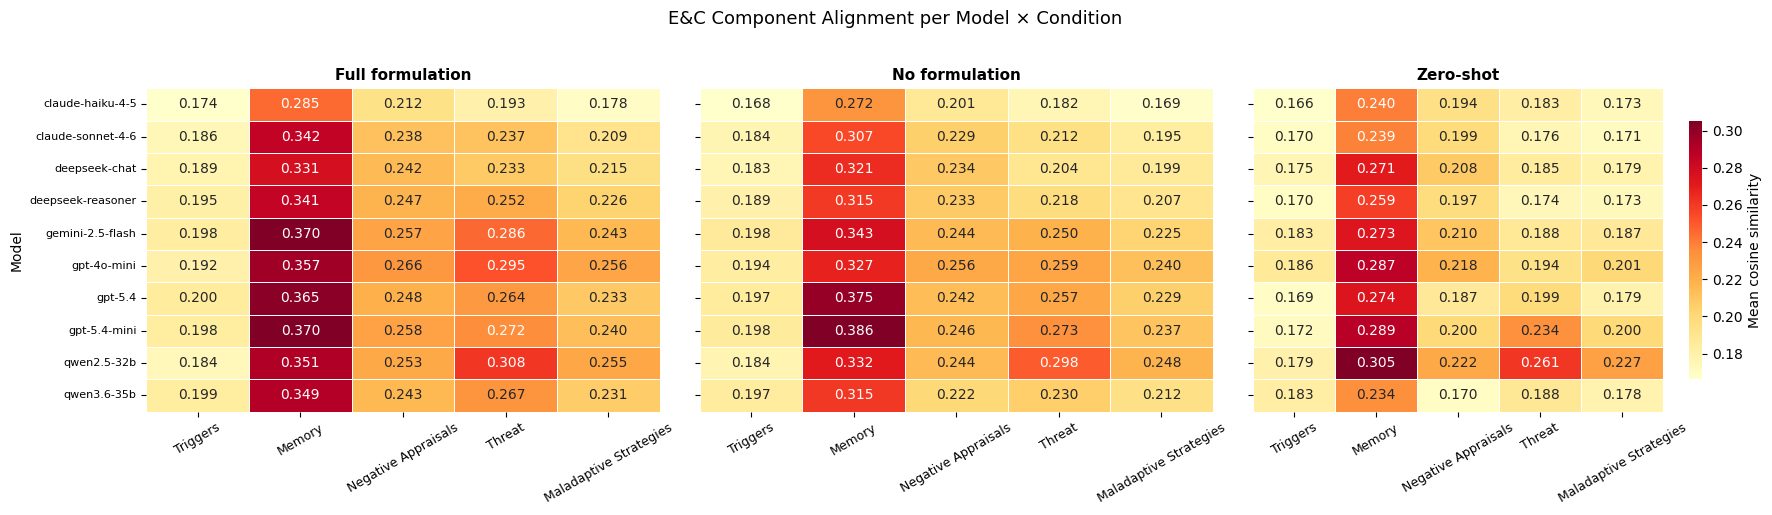

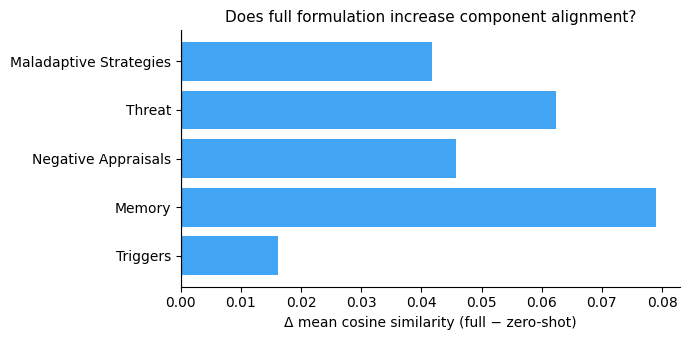

Full − Zero-shot Δ:
Triggers                  0.0161
Memory                    0.0790
Negative Appraisals       0.0458
Threat                    0.0624
Maladaptive Strategies    0.0417

Correlation — node weight vs alignment (full condition):
  Triggers                   r = +0.148
  Memory                     r = +0.381
  Negative Appraisals        r = +0.202
  Threat                     r = +0.230
  Maladaptive Strategies     r = +0.102


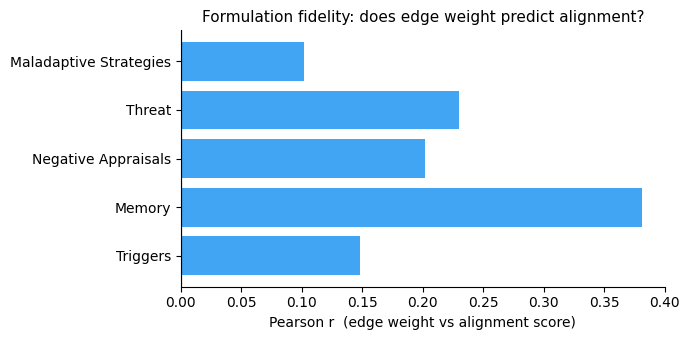


Saved: component_alignment_heatmap.png  |  component_alignment_delta.png  |  component_weight_correlation.png


In [ ]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from configs.self_report import (
    TRIGGERS, MEMORY, NEGATIVE_APPRAISALS, THREAT,
    DISTRACTION_STRATEGIES, AVOIDANCE_STRATEGIES, MALADAPTIVE_STRATEGIES,
)

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

# ── 0. Load vignette df and embeddings from cache ────────────────────────────
_df        = pd.read_parquet(ANALYSIS_DIR / "all_vignettes.parquet")
_embeddings = np.load(ANALYSIS_DIR / "embeddings_mpnet.npy")
assert len(_df) == len(_embeddings), "Cache mismatch — delete and rerun cells 1-2"
print(f"Loaded {len(_df)} vignettes + embeddings")

# ── 1. Build component phrase lists ──────────────────────────────────────────
COMPONENTS = {
    "Triggers":               list(TRIGGERS.values()),
    "Memory":                 list(MEMORY.values()),
    "Negative Appraisals":    list(NEGATIVE_APPRAISALS.values()),
    "Threat":                 list(THREAT.values()),
    "Maladaptive Strategies": list(DISTRACTION_STRATEGIES.values())
                            + list(AVOIDANCE_STRATEGIES.values())
                            + list(MALADAPTIVE_STRATEGIES.values()),
}
print("\nComponent phrase counts:")
for name, phrases in COMPONENTS.items():
    print(f"  {name:<25} {len(phrases)} phrases")

# ── 2. Embed component phrases (cached) ──────────────────────────────────────
COMP_EMB_CACHE = ANALYSIS_DIR / "component_embeddings.npz"

if COMP_EMB_CACHE.exists():
    _c = np.load(COMP_EMB_CACHE, allow_pickle=True)
    component_embs = {k: _c[k] for k in _c.files}
    print(f"\nLoaded cached component embeddings")
else:
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer("all-mpnet-base-v2")
    component_embs = {}
    for name, phrases in COMPONENTS.items():
        emb = enc.encode(phrases, normalize_embeddings=True, show_progress_bar=False)
        component_embs[name] = emb
        print(f"  Embedded {name}: {emb.shape}")
    np.savez(COMP_EMB_CACHE, **component_embs)
    print(f"Saved -> {COMP_EMB_CACHE}")

# ── 3. Compute alignment scores (cached) ─────────────────────────────────────
ALIGN_CACHE = ANALYSIS_DIR / "component_alignment.parquet"

if ALIGN_CACHE.exists():
    align_df = pd.read_parquet(ALIGN_CACHE)
    print(f"Loaded cached alignment scores: {len(align_df)} rows")
else:
    print(f"Computing alignment for {len(_df)} vignettes...")
    rows = []
    for i, row in _df.iterrows():
        emb    = _embeddings[i]
        scores = {name: float((component_embs[name] @ emb).mean())
                  for name in COMPONENTS}
        scores["persona_id"] = row["persona_id"]
        scores["model"]      = row["model"]
        scores["condition"]  = row["condition"]
        rows.append(scores)
    align_df = pd.DataFrame(rows)
    align_df.to_parquet(ALIGN_CACHE, index=False)
    print(f"Saved -> {ALIGN_CACHE}")

COMP_NAMES = list(COMPONENTS.keys())

# ── 4. Heatmap: mean alignment per model × condition ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (cond, label) in zip(axes, CONDITION_LABELS.items()):
    sub   = align_df[(align_df["condition"] == cond) & (align_df["model"].isin(_EVAL_MODELS))]
    pivot = sub.groupby("model")[COMP_NAMES].mean().reindex(_EVAL_MODELS).dropna()
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.4, cbar=(ax == axes[-1]),
                cbar_kws={"label": "Mean cosine similarity", "shrink": 0.8})
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Model" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("E&C Component Alignment per Model × Condition", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "component_alignment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Condition delta: full vs zero_shot ────────────────────────────────────
full_means = align_df[align_df["condition"] == "full"][COMP_NAMES].mean()
zs_means   = align_df[align_df["condition"] == "zero_shot"][COMP_NAMES].mean()
delta      = full_means - zs_means

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#2196F3" if v >= 0 else "#EF5350" for v in delta.values]
ax.barh(delta.index, delta.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Δ mean cosine similarity (full − zero-shot)")
ax.set_title("Does full formulation increase component alignment?", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "component_alignment_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print("Full − Zero-shot Δ:")
print(delta.round(4).to_string())

# ── 6. Full condition: edge weight vs alignment correlation ───────────────────
FULL_DIR = Path("../data/output/full")
ec_rows  = []
for model_dir in sorted(FULL_DIR.iterdir()):
    if not model_dir.is_dir() or model_dir.name not in _EVAL_MODELS:
        continue
    for fp in model_dir.glob("experiment_*.json"):
        try:
            with open(fp, encoding="utf-8") as f:
                data = json.load(f)
            pid        = data.get("persona_id")
            raw_edges  = data.get("agg_edges", {})
            node_weights = {n: [] for n in COMPONENTS}
            for edge_key, w in raw_edges.items():
                if w <= 0:
                    continue
                parts = edge_key.split(" -- ")
                if len(parts) != 2:
                    continue
                src, tgt = parts
                if src in node_weights: node_weights[src].append(w)
                if tgt in node_weights: node_weights[tgt].append(w)
            ec_rows.append({
                "persona_id": pid,
                "model":      model_dir.name,
                **{f"weight_{n}": (np.mean(v) if v else 0.0) for n, v in node_weights.items()},
            })
        except Exception:
            continue

weight_df = pd.DataFrame(ec_rows)
merged    = align_df[align_df["condition"] == "full"].merge(
                weight_df, on=["persona_id", "model"], how="inner")

print("\nCorrelation — node weight vs alignment (full condition):")
corr_rows = []
for comp in COMP_NAMES:
    w_col = f"weight_{comp}"
    if w_col not in merged.columns:
        continue
    r = merged[[comp, w_col]].corr().iloc[0, 1]
    print(f"  {comp:<25}  r = {r:+.3f}")
    corr_rows.append({"component": comp, "r": r})

corr_df = pd.DataFrame(corr_rows)
fig, ax = plt.subplots(figsize=(7, 3.5))
colors  = ["#2196F3" if v >= 0 else "#EF5350" for v in corr_df["r"]]
ax.barh(corr_df["component"], corr_df["r"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r  (edge weight vs alignment score)")
ax.set_title("Formulation fidelity: does edge weight predict alignment?", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "component_weight_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: component_alignment_heatmap.png  |  component_alignment_delta.png  |  component_weight_correlation.png")

## 10. Token usage & iteration statistics per model × condition

C:\Users\amit\AppData\Local\Temp\ipykernel_25736\2471136760.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
C:\Users\amit\AppData\Local\Temp\ipykernel_25736\2471136760.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
C:\Users\amit\AppData\Local\Temp\ipykernel_25736\2471136760.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)


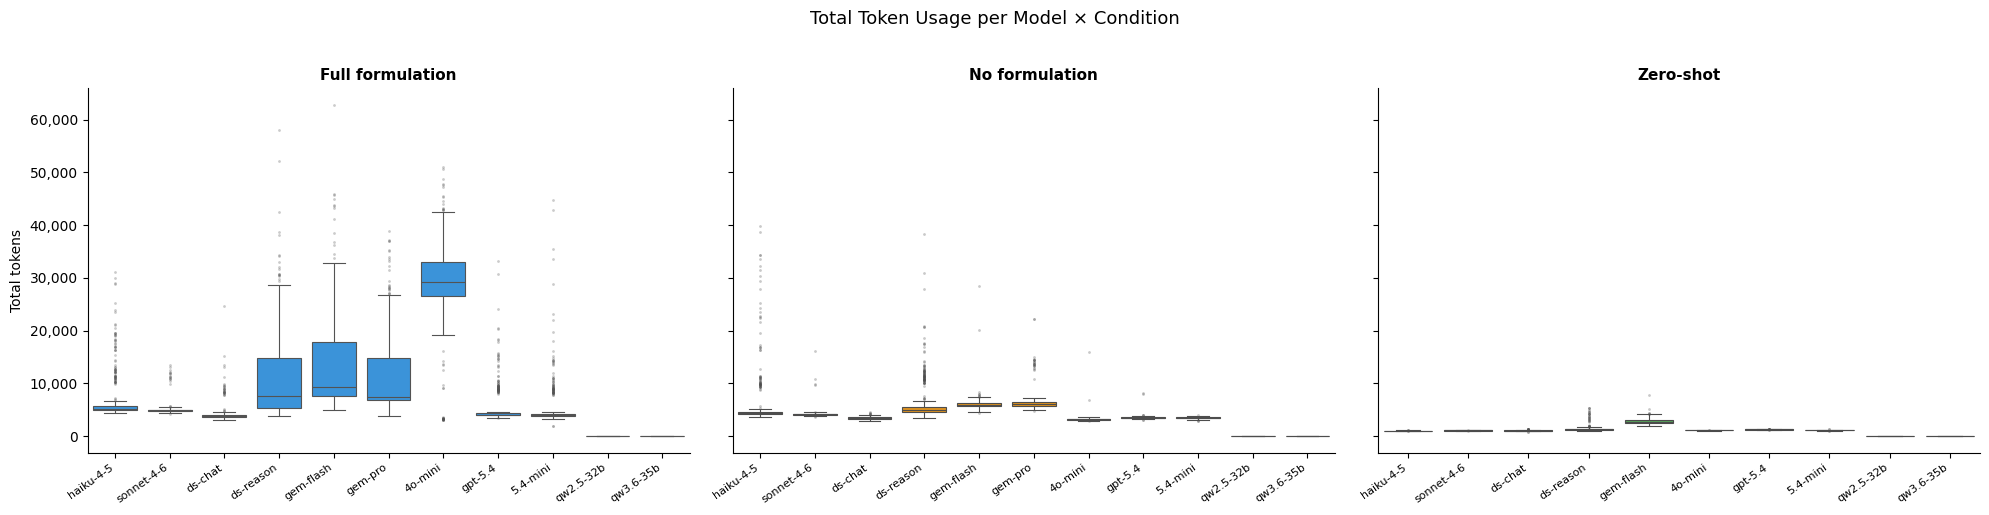

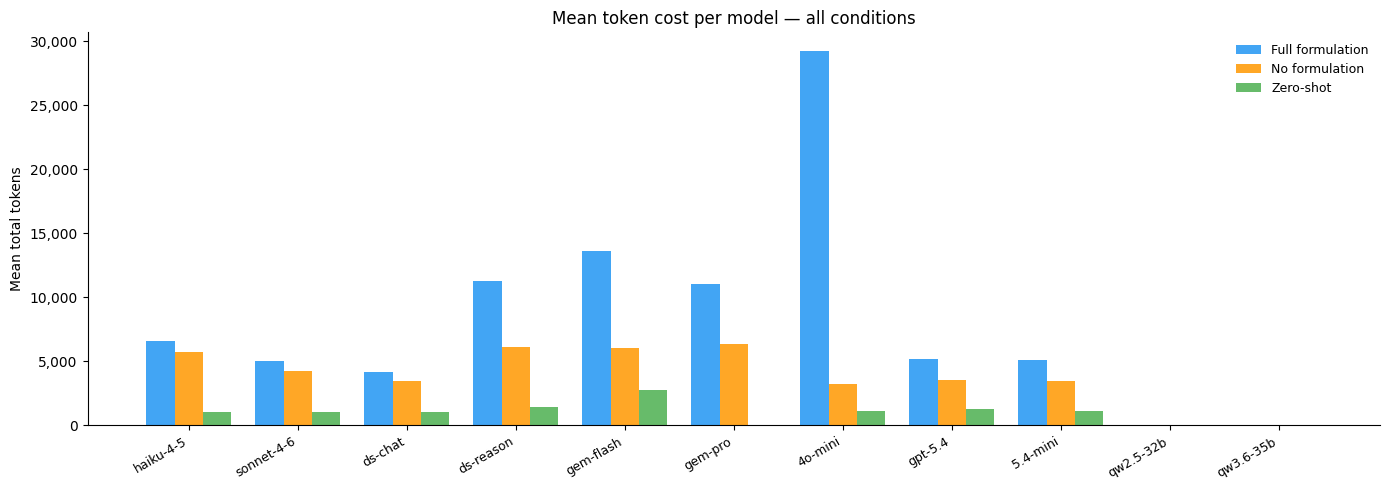

Mean total tokens per model × condition:
                   Full formulation  No formulation  Zero-shot
model                                                         
claude-haiku-4-5               6602            5768       1007
claude-sonnet-4-6              5062            4214       1062
deepseek-chat                  4159            3479       1050
deepseek-reasoner             11292            6108       1443
gemini-2.5-flash              13636            6075       2773
gemini-2.5-pro                11024            6379       <NA>
gpt-4o-mini                   29234            3238       1091
gpt-5.4                        5187            3539       1255
gpt-5.4-mini                   5144            3472       1111
qwen2.5-32b                       0               0          0
qwen3.6-35b                       0               0          0


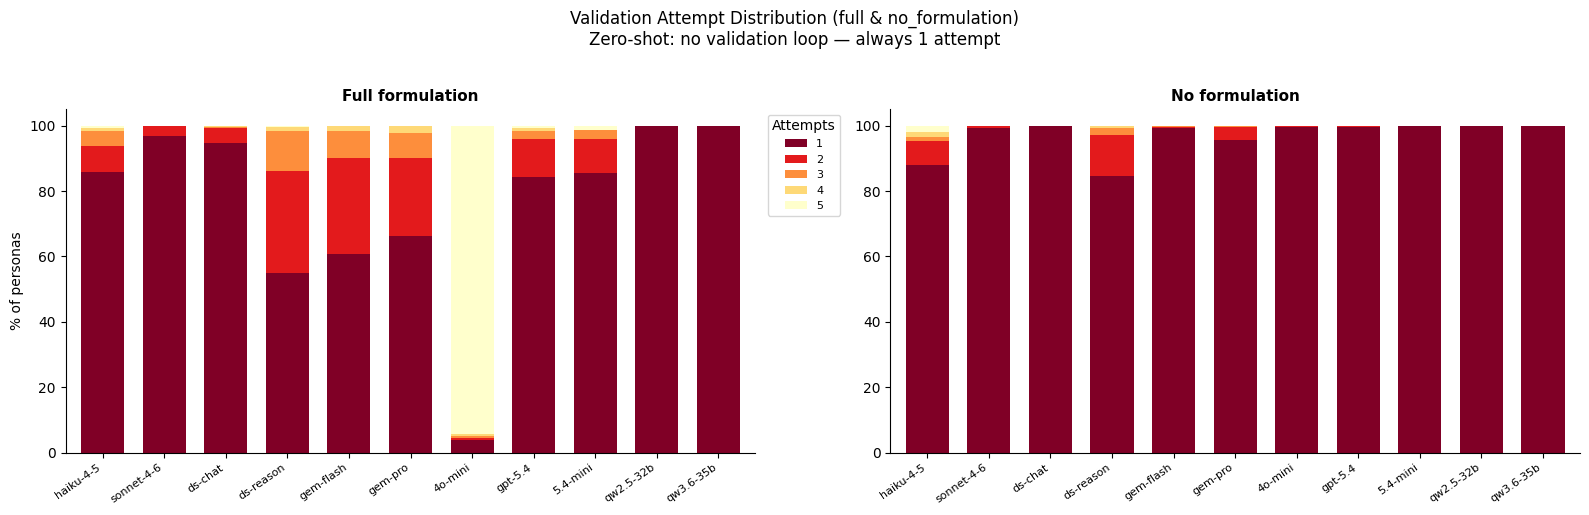

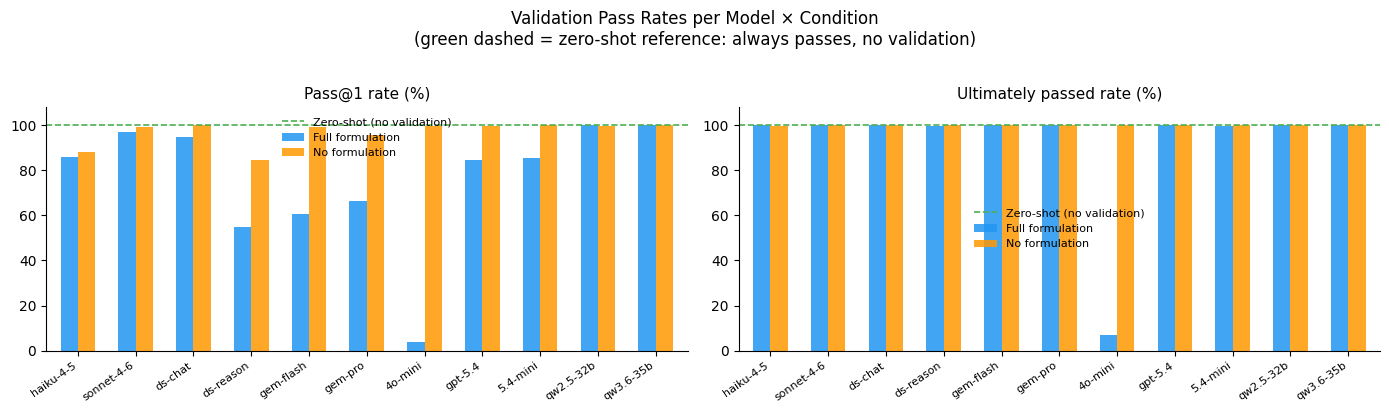


Saved: tokens_boxplot.png | tokens_grouped_bar.png | iterations_stacked_bar.png | pass_rates.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#2196F3", "no_formulation": "#FF9800", "zero_shot": "#4CAF50"}

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]
SHORT_MODEL = {
    "claude-haiku-4-5":   "haiku-4-5",
    "claude-sonnet-4-6":  "sonnet-4-6",
    "deepseek-chat":      "ds-chat",
    "deepseek-reasoner":  "ds-reason",
    "gemini-2.5-flash":   "gem-flash",
    "gemini-2.5-pro":     "gem-pro",
    "gpt-4o-mini":        "4o-mini",
    "gpt-5.4":            "gpt-5.4",
    "gpt-5.4-mini":       "5.4-mini",
    "qwen2.5-32b":        "qw2.5-32b",
    "qwen3.6-35b":        "qw3.6-35b",
}

long = pd.read_csv(ANALYSIS_DIR / "personas_long.csv")
long = long[long["model"].isin(_EVAL_MODELS)]
long["model_short"]     = long["model"].map(SHORT_MODEL)
long["condition_label"] = long["condition"].map(CONDITION_LABELS)

# ── 1. Token box plots — one panel per condition ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for ax, (cond, label) in zip(axes, CONDITION_LABELS.items()):
    sub   = long[long["condition"] == cond]
    order = [SHORT_MODEL[m] for m in _EVAL_MODELS if SHORT_MODEL[m] in sub["model_short"].values]
    sns.boxplot(data=sub, x="model_short", y="tokens_total", order=order,
                color=CONDITION_COLORS[cond], ax=ax,
                flierprops=dict(marker=".", markersize=2, alpha=0.3),
                linewidth=0.8)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Total tokens" if ax == axes[0] else "")
    ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Total Token Usage per Model × Condition", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tokens_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Combined grouped bar: mean tokens all 3 conditions per model ───────────
pivot_tokens = (
    long.groupby(["model", "condition"])["tokens_total"]
    .mean()
    .unstack("condition")
    [[c for c in CONDITION_LABELS if c in long["condition"].unique()]]
)
pivot_tokens.columns = [CONDITION_LABELS[c] for c in pivot_tokens.columns]
pivot_tokens.index   = [SHORT_MODEL.get(m, m) for m in pivot_tokens.index]
pivot_tokens = pivot_tokens.reindex([SHORT_MODEL[m] for m in _EVAL_MODELS if SHORT_MODEL[m] in pivot_tokens.index])

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(pivot_tokens))
w = 0.26
for i, (col, color) in enumerate(zip(pivot_tokens.columns, CONDITION_COLORS.values())):
    ax.bar(x + (i - 1) * w, pivot_tokens[col], width=w, label=col, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot_tokens.index, rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Mean total tokens")
ax.set_title("Mean token cost per model — all conditions", fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tokens_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Mean tokens table — raw model names as in config ──────────────────────
pivot_raw = (
    long.groupby(["model", "condition"])["tokens_total"]
    .mean()
    .unstack("condition")
    [[c for c in CONDITION_LABELS if c in long["condition"].unique()]]
)
pivot_raw.columns = [CONDITION_LABELS[c] for c in pivot_raw.columns]
pivot_raw = pivot_raw.reindex([m for m in _EVAL_MODELS if m in pivot_raw.index])
print("Mean total tokens per model × condition:")
print(pivot_raw.round(0).astype("Int64").to_string(na_rep="—"))

# ── 4. Iteration distribution — full & no_formulation only ───────────────────
iter_df = long[long["condition"].isin(["full", "no_formulation"])].copy()
iter_df["n_attempts_capped"] = iter_df["n_attempts"].clip(upper=5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, cond in zip(axes, ["full", "no_formulation"]):
    sub   = iter_df[iter_df["condition"] == cond]
    order = [SHORT_MODEL[m] for m in _EVAL_MODELS if SHORT_MODEL[m] in sub["model_short"].values]
    attempt_counts = (
        sub.groupby(["model_short", "n_attempts_capped"])
        .size().unstack(fill_value=0).reindex(order)
    )
    attempt_pct = attempt_counts.div(attempt_counts.sum(axis=1), axis=0) * 100
    attempt_pct.plot(kind="bar", stacked=True, ax=ax, width=0.7,
                     colormap="YlOrRd_r", legend=(ax == axes[0]))
    ax.set_title(CONDITION_LABELS[cond], fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("% of personas" if ax == axes[0] else "")
    ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)
    if ax == axes[0]:
        ax.legend(title="Attempts", bbox_to_anchor=(1.01, 1), loc="upper left",
                  labels=[str(c) if c < 5 else "5" for c in attempt_pct.columns],
                  fontsize=8)

plt.suptitle("Validation Attempt Distribution (full & no_formulation)\nZero-shot: no validation loop — always 1 attempt",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "iterations_stacked_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Pass rates ─────────────────────────────────────────────────────────────
pass_summary = (
    long[long["condition"].isin(["full", "no_formulation"])]
    .groupby(["model", "condition"])
    .agg(pass_at_1=("attempt_1_passed", "mean"),
         ultimately_passed=("ultimately_passed", "mean"))
    * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (metric, title) in zip(axes, [
    ("pass_at_1",        "Pass@1 rate (%)"),
    ("ultimately_passed","Ultimately passed rate (%)"),
]):
    pivot = pass_summary[metric].unstack("condition")
    pivot = pivot[[c for c in ["full", "no_formulation"] if c in pivot.columns]]
    pivot.columns = [CONDITION_LABELS[c] for c in pivot.columns]
    pivot = pivot.reindex(_EVAL_MODELS).dropna(how="all")
    pivot.index = [SHORT_MODEL.get(m, m) for m in pivot.index]
    pivot.plot(kind="bar", ax=ax, width=0.6, alpha=0.85,
               color=["#2196F3", "#FF9800"])
    ax.axhline(100, color="#4CAF50", linewidth=1.2, linestyle="--",
               label="Zero-shot (no validation)")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_xticklabels(pivot.index, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 108)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Validation Pass Rates per Model × Condition\n(green dashed = zero-shot reference: always passes, no validation)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "pass_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: tokens_boxplot.png | tokens_grouped_bar.png | iterations_stacked_bar.png | pass_rates.png")

## 9. Persona identity preservation
For each persona, how similar are the vignettes generated by different models?  
**Within-persona** = same persona, different models. **Between-persona** = different personas, same condition.  
Higher within-persona similarity → models agree on how to portray that persona.

Loaded 14981 vignettes + embeddings


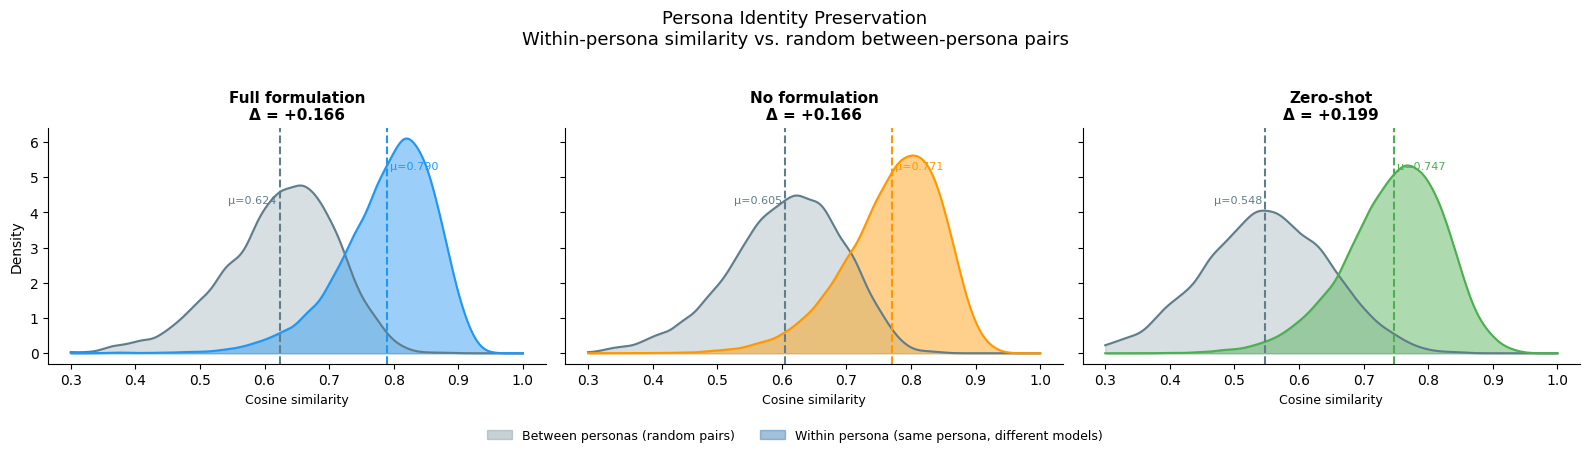

Condition                 Within   Between   Δ (within − between)
-----------------------------------------------------------------
Full formulation           0.7896   0.6238   +0.1658
No formulation             0.7710   0.6053   +0.1657
Zero-shot                  0.7469   0.5477   +0.1993
Saved -> ..\data\analysis/persona_identity_distributions.png
Saved -> ..\data\analysis/persona_consistency_heatmap.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
from pathlib import Path
from scipy.stats import gaussian_kde

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#2196F3", "no_formulation": "#FF9800", "zero_shot": "#4CAF50"}

# ── 0. Load from cache ────────────────────────────────────────────────────────
_df         = pd.read_parquet(ANALYSIS_DIR / "all_vignettes.parquet")
_embeddings = np.load(ANALYSIS_DIR / "embeddings_mpnet.npy")
assert len(_df) == len(_embeddings), "Cache mismatch — delete and rerun cells 1-2"
print(f"Loaded {len(_df)} vignettes + embeddings")

# ── 1. Compute within- vs between-persona similarities ───────────────────────
N_BETWEEN_SAMPLE = 5000

dist_rows = []
for cond in CONDITION_LABELS:
    mask  = _df["condition"] == cond
    sub   = _df[mask].reset_index(drop=True)
    embs  = _embeddings[mask.values]
    pids  = sub["persona_id"].values

    pid_to_idxs = {}
    for i, pid in enumerate(pids):
        pid_to_idxs.setdefault(pid, []).append(i)

    within_sims = []
    for pid, idxs in pid_to_idxs.items():
        if len(idxs) < 2:
            continue
        for i, j in combinations(idxs, 2):
            within_sims.append(float(embs[i] @ embs[j]))

    rng = np.random.default_rng(42)
    n   = len(sub)
    between_sims = []
    attempts = 0
    while len(between_sims) < N_BETWEEN_SAMPLE and attempts < N_BETWEEN_SAMPLE * 10:
        i, j = rng.integers(0, n, size=2)
        if pids[i] != pids[j]:
            between_sims.append(float(embs[i] @ embs[j]))
        attempts += 1

    for s in within_sims:
        dist_rows.append({"condition": cond, "type": "within", "similarity": s})
    for s in between_sims:
        dist_rows.append({"condition": cond, "type": "between", "similarity": s})

dist_df = pd.DataFrame(dist_rows)

# ── 2. KDE overlap plot — one panel per condition ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
x_grid = np.linspace(0.3, 1.0, 500)

for ax, (cond, label) in zip(axes, CONDITION_LABELS.items()):
    col = CONDITION_COLORS[cond]
    sub = dist_df[dist_df["condition"] == cond]

    within  = sub[sub["type"] == "within"]["similarity"].values
    between = sub[sub["type"] == "between"]["similarity"].values

    kde_w = gaussian_kde(within,  bw_method=0.15)
    kde_b = gaussian_kde(between, bw_method=0.15)

    y_w = kde_w(x_grid)
    y_b = kde_b(x_grid)

    ax.fill_between(x_grid, y_b, alpha=0.35, color="#90A4AE", label="Between personas")
    ax.fill_between(x_grid, y_w, alpha=0.45, color=col,       label="Within persona")
    ax.plot(x_grid, y_b, color="#607D8B", linewidth=1.5)
    ax.plot(x_grid, y_w, color=col,       linewidth=1.5)

    # mean lines
    mw = within.mean()
    mb = between.mean()
    ax.axvline(mw, color=col,      linewidth=1.5, linestyle="--")
    ax.axvline(mb, color="#607D8B", linewidth=1.5, linestyle="--")

    # annotations
    ax.text(mw + 0.005, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 5,
            f"μ={mw:.3f}", color=col, fontsize=8, va="top")
    ax.text(mb - 0.005, ax.get_ylim()[1] * 0.7 if ax.get_ylim()[1] > 0 else 4,
            f"μ={mb:.3f}", color="#607D8B", fontsize=8, va="top", ha="right")

    delta = mw - mb
    ax.set_title(f"{label}\nΔ = {delta:+.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Cosine similarity", fontsize=9)
    ax.set_ylabel("Density" if ax == axes[0] else "")
    ax.spines[["top", "right"]].set_visible(False)

patch_w = mpatches.Patch(color="#90A4AE", alpha=0.5, label="Between personas (random pairs)")
patch_b = mpatches.Patch(color="steelblue", alpha=0.5, label="Within persona (same persona, different models)")
fig.legend(handles=[patch_w, patch_b], loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.suptitle("Persona Identity Preservation\nWithin-persona similarity vs. random between-persona pairs",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "persona_identity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Condition                 Within   Between   Δ (within − between)")
print("-" * 65)
for cond, label in CONDITION_LABELS.items():
    sub = dist_df[dist_df["condition"] == cond]
    w = sub[sub["type"] == "within"]["similarity"].mean()
    b = sub[sub["type"] == "between"]["similarity"].mean()
    print(f"{label:<25}  {w:.4f}   {b:.4f}   {w - b:+.4f}")


print(f"Saved -> {ANALYSIS_DIR}/persona_identity_distributions.png")
print(f"Saved -> {ANALYSIS_DIR}/persona_consistency_heatmap.png")

Loaded cached emotion scores: 14981 rows
                anger  disgust   fear    joy  neutral  sadness  surprise
condition                                                               
full            0.035    0.099  0.802  0.001    0.025    0.029     0.009
no_formulation  0.031    0.121  0.774  0.001    0.033    0.029     0.012
zero_shot       0.034    0.158  0.615  0.002    0.129    0.045     0.017


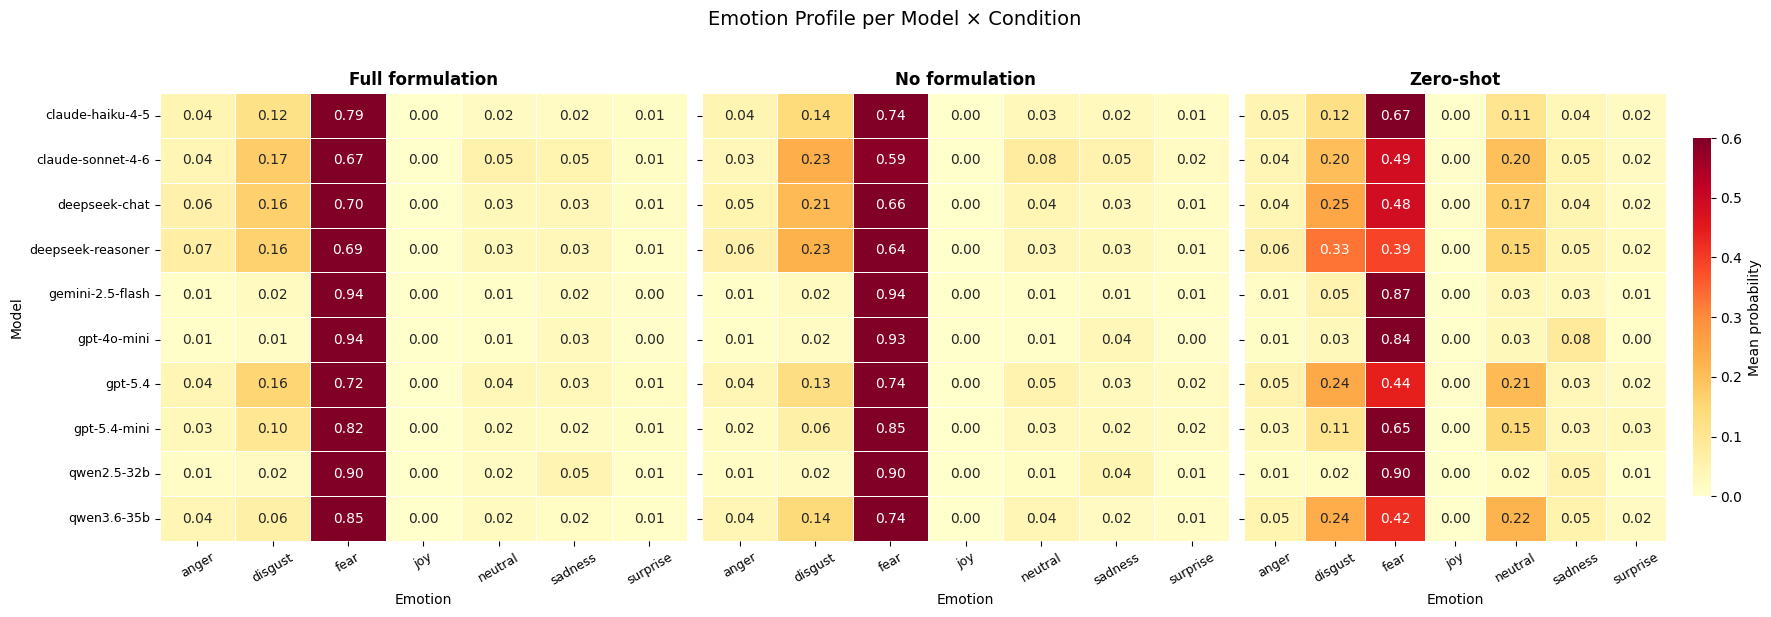

Saved -> ..\data\analysis/emotion_heatmap.png


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import pipeline

ANALYSIS_DIR  = Path("../data/analysis")
EMO_CACHE     = ANALYSIS_DIR / "emotion_scores.parquet"

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
EMOTIONS = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

# ── 1. Compute or load ────────────────────────────────────────────────────────
if EMO_CACHE.exists():
    emo_df = pd.read_parquet(EMO_CACHE)
    print(f"Loaded cached emotion scores: {len(emo_df)} rows")
else:
    vig_cache = ANALYSIS_DIR / "all_vignettes.parquet"
    df_v = pd.read_parquet(vig_cache)
    print(f"Scoring {len(df_v)} vignettes...")

    clf = pipeline(
        "text-classification",
        model="j-hartmann/emotion-english-distilroberta-base",
        top_k=None,
        truncation=True,
        max_length=512,
        device=-1,       # CPU; set device=0 for GPU
    )

    records = []
    batch_size = 32
    texts = df_v["vignette"].tolist()
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        results = clf(batch)
        for j, res in enumerate(results):
            row = {r["label"]: r["score"] for r in res}
            row["_idx"] = i + j
            records.append(row)
        if i % 1000 == 0:
            print(f"  {i}/{len(texts)}")

    scores = pd.DataFrame(records).set_index("_idx").reindex(columns=EMOTIONS).fillna(0)
    emo_df = pd.concat([df_v[["persona_id", "model", "condition"]].reset_index(drop=True),
                        scores.reset_index(drop=True)], axis=1)
    emo_df.to_parquet(EMO_CACHE, index=False)
    print(f"Saved -> {EMO_CACHE}")

print(emo_df.groupby("condition")[EMOTIONS].mean().round(3))

# ── 2. Heatmap: mean emotion per model × condition ────────────────────────────
_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (cond, label) in zip(axes, CONDITION_LABELS.items()):
    sub = emo_df[(emo_df["condition"] == cond) & (emo_df["model"].isin(_EVAL_MODELS))]
    pivot = sub.groupby("model")[EMOTIONS].mean().reindex(_EVAL_MODELS)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=0.6, linewidths=0.4,
                cbar=(ax == axes[-1]),
                cbar_kws={"label": "Mean probability", "shrink": 0.8})
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Emotion"); ax.set_ylabel("" if ax != axes[0] else "Model")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Emotion Profile per Model × Condition", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "emotion_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/emotion_heatmap.png")

